In [6]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [7]:
from sklearn.datasets import fetch_openml

# Fetch the dataset
iris = fetch_openml(data_id=61, as_frame=True)

# Extract features and target
X = iris.data
y = iris.target

# Display the first few rows of the dataset
print(X.head())
print(y.head())


   sepallength  sepalwidth  petallength  petalwidth
0          5.1         3.5          1.4         0.2
1          4.9         3.0          1.4         0.2
2          4.7         3.2          1.3         0.2
3          4.6         3.1          1.5         0.2
4          5.0         3.6          1.4         0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: category
Categories (3, object): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [9]:
# Step 2: Normalize features (needed for kNN)
from sklearn.preprocessing import StandardScaler # Import StandardScaler from sklearn.preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Optimal k: 15 with accuracy: 0.967


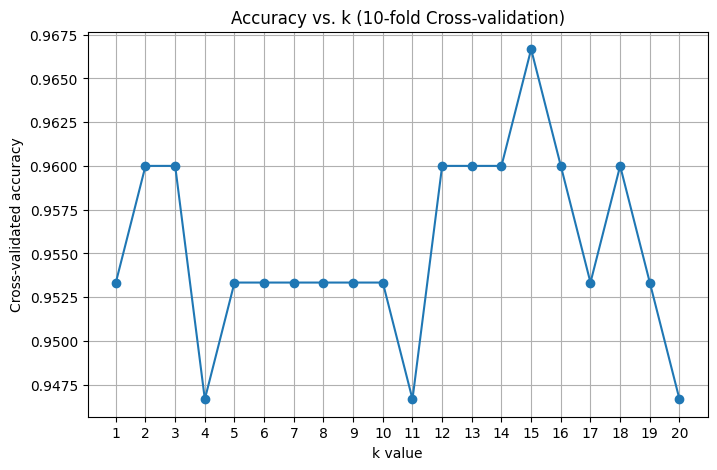

In [11]:
# kNN Classifier with 10-fold cross-validation
from sklearn.model_selection import cross_val_score # Import cross_val_score

k_range = range(1, 21)
scores = []

# 10-fold cross-validation to find optimal k
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=kf, scoring='accuracy').mean()
    scores.append(score)

# Find optimal k
optimal_k = k_range[np.argmax(scores)]
print(f'Optimal k: {optimal_k} with accuracy: {max(scores):.3f}')

# Plot to visualize accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_range, scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Cross-validated accuracy')
plt.title('Accuracy vs. k (10-fold Cross-validation)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [12]:
# Now classify using optimal k
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
y_pred = cross_val_predict(knn_best, X_scaled, y, cv=kf)

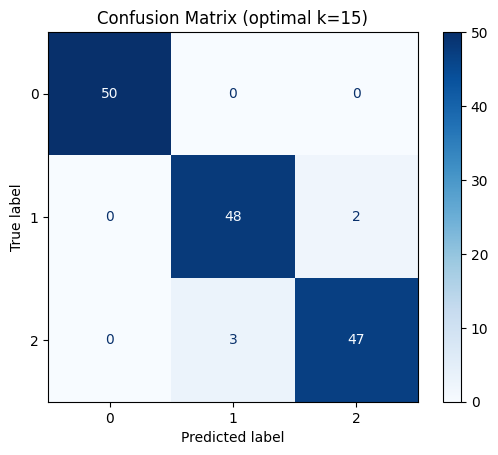

In [13]:
# Confusion Matrix for optimal k
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (optimal k={optimal_k})')
plt.show()

In [14]:
# Classification Report
report = classification_report(y, y_pred, digits=3)
print('Classification Report:\n', report)
#macro avg. is to average the corresponding value with equal weighted.
#weighted avg. is to average with weight of support (no. of datapoint), good for imbalanced data.

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        50
Iris-versicolor      0.941     0.960     0.950        50
 Iris-virginica      0.959     0.940     0.949        50

       accuracy                          0.967       150
      macro avg      0.967     0.967     0.967       150
   weighted avg      0.967     0.967     0.967       150

